In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [2]:
from importlib import reload
import sys
import scipy as sp

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

from importlib import reload
from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 5 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., # karin had 0.65 
    "pi_prior" : 1.
}

cpu


In [5]:
hypers["eta"]

0.2

### Load data

In [6]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain/train/'

# read each file in the input_files_folder (h5) files and concatenate them all into the summarized_data object 
files = os.listdir(input_files_folder)
df_list = []
for file in files:
    if file.endswith(".h5"):
        path_with_quotes = input_files_folder + file
        fixed_path = path_with_quotes.replace("'", "")
        df = pd.read_hdf(fixed_path, 'df')
        df_list.append(df)
    else:
        pass
# concatenate all dataframes
summarized_data = pd.concat(df_list, ignore_index=True)
summarized_data.head()


,cell_id,Cluster,Cluster_Counts,junction_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index
0,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,422,16,1_34299838_34301860,8,Brain_Non-Myeloid_brain_pericyte,0.500000,92,35150
1,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,422,16,1_34301932_34302829,8,Brain_Non-Myeloid_brain_pericyte,0.500000,92,35152
2,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,423,30,1_34303032_34303420,16,Brain_Non-Myeloid_brain_pericyte,0.533333,92,35153
3,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,423,30,1_34303531_34306527,14,Brain_Non-Myeloid_brain_pericyte,0.466667,92,35155
4,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,469,28,1_36307836_36316208,7,Brain_Non-Myeloid_brain_pericyte,0.250000,92,35177


In [7]:
print(len(summarized_data.cell_id.unique())) # num cells 
print(len(summarized_data.junction_id.unique())) # num junctions
print(len(summarized_data.Cluster.unique())) # num Cluster

5499
78814
17976


In [8]:
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
    input_folder = input_files_folder) 

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain/train/
Finished reading in data from folder ...
['Brain_Non-Myeloid_brain_pericyte' 'Brain_Myeloid_microglial_cell'
 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_astrocyte' 'Brain_Non-Myeloid_endothelial_cell'
 'Brain_Non-Myeloid_neuron' 'Brain_Non-Myeloid_Bergmann_glial_cell'
 'Brain_Myeloid_macrophage']
5499
78813
The number of junctions in the data is:  78814
The number of cells in the data is:  5499
The number of cell types in the data is:  9


In [9]:
# still do preprocessing in scipy
import plotnine as p9
import scipy.sparse as sp
import matplotlib.pyplot as plt 

indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [10]:
# for simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions where 
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = summarized_data[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

In [11]:
# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]
# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

4732


In [12]:
# write function that takes in Cluster name 
def check_SS_cluster(cluster_name):
    
    juncs_c = junc_info[junc_info["Cluster"] == cluster_name]
    
    # keep only rows where either start or end appear twice
    s = np.array(juncs_c[juncs_c.duplicated(subset=['start'])].start.unique())
    e = np.array(juncs_c[juncs_c.duplicated(subset=['end'])].end.unique())
    juncs_c = juncs_c[(juncs_c["start"].isin(s)) | (juncs_c["end"].isin(e))]

    # if num rows in juncs_c is 3 then return cluster name 
    if len(juncs_c) == 3:
        return cluster_name
    else:
        pass

# run function on all clusters 
clusters_SS = []

for cluster in junc_info["Cluster"].unique():
    clusters_SS.append(check_SS_cluster(cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

4262


In [13]:
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)]
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type
1,0,191,54.0,126,72.0,0.428571,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
2,0,192,18.0,126,108.0,0.142857,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
3,0,193,54.0,126,72.0,0.428571,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
5,0,247,4.0,4,0.0,1.000000,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell
13,0,338,46.0,46,0.0,1.000000,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell


In [14]:
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]
junction_ids_conversion["new_junction_id_index"] = np.arange(junction_ids_conversion.shape[0])

In [15]:
junction_ids_conversion

,junction_id_index,junction_id,Cluster,new_junction_id_index
36567,2,10_100080130_100080856,74169,0
1128871,3,10_100080130_100087346,74169,1
36568,4,10_100080940_100087346,74169,2
12569006,5,10_100478022_100485050,77482,3
60859,6,10_100478022_100487161,77482,4
...,...,...,...,...
13798783,78503,Y_1280439_1284321,130760,12781
10517,78504,Y_1282948_1284321,130760,12782
256755,78517,Y_58849553_58853447,130771,12783
21666744,78518,Y_58849553_58853675,130771,12784


In [16]:
# re-order the remaining junctions 
final_data = final_data.merge(junction_ids_conversion, on = "junction_id_index")

In [17]:
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)

In [18]:
final_data.tail()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index
2685231,412,78519,6.0,6,0.0,1.0,B11-B003281-3_39_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,Y_58849553_58854847,130771,12785
2685232,413,78519,3.0,3,0.0,1.0,B11-B003292-3_39_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,Y_58849553_58854847,130771,12785
2685233,418,78519,1.0,1,0.0,1.0,B11-MAA000591-3_8_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,Y_58849553_58854847,130771,12785
2685226,392,78519,9.0,9,0.0,1.0,B10-B000825-3_38_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,Y_58849553_58854847,130771,12785
2685405,1538,78519,2.0,2,0.0,1.0,E20-B000825-3_38_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,Y_58849553_58854847,130771,12785


In [19]:
to_keep = final_data["junction_id_index"].unique()   
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

In [20]:
print(junc_counts_sub.toarray()[392, 12785])
print(cluster_counts_sub.toarray()[392, 12785])

9.0
9


### Simulate Data

In [21]:
import pdb as pdb

In [61]:
def simulate_junc_counts(cluster_counts, cell_types=None, simulate_cell_types=False, psi_prior_shape1=0.5, psi_prior_shape2=0.5):
    
    """Simulate junc counts while keeping the cluster counts of observed data. 
    
    Args: 
        cluster_counts: scipy coo_matrix. 
        cell_types: pandas Categorical series of pre-defined cell types to use for simulations 
        simulate_cell_types: bool. If True, simulate cell types with default K of 2.
    """
    
    N, P = cluster_counts.shape  # number of cells, number of junctions
     
    if cell_types is not None:
        print("Using pre-defined cell types!")
        K = len(cell_types.cat.categories)  # number of cell types
    
    if simulate_cell_types:
        print("Simulating cell types!")
        K = 2  # going to simulate two cell types and randomly assign them to cells
        cell_types = pd.Categorical(np.random.choice(K, N))

    print(N, P, K, len(cell_types))
    
    # simulate PSI for each junction in each cell type via pre-defined beta distributions
    cell_type_psi = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([P, K]) 
    print("Done simulating PSI!")

    # use real cluster counts to simulate junc counts with binomial distribution
    sim_junc_counts = cluster_counts.copy() 

    sim_junc_counts.data = torch.distributions.binomial.Binomial( 
         total_count=torch.tensor(cluster_counts.data), 
         probs=cell_type_psi[
             cluster_counts.col, 
             cell_types[cluster_counts.row] #use cell type of each cell to get the corresponding psi
         ]
    ).sample().numpy()
    print("Done simulating junc counts!")
    
    return sim_junc_counts, cell_types, cell_type_psi

In [62]:
simulated_counts, cell_types, cell_type_psi = simulate_junc_counts(cluster_counts_sub, cell_types=None, simulate_cell_types = True)

Simulating cell types!
5499 12786 2 5499
Done simulating PSI!


Done simulating junc counts!


<Axes: xlabel='difference', ylabel='Count'>

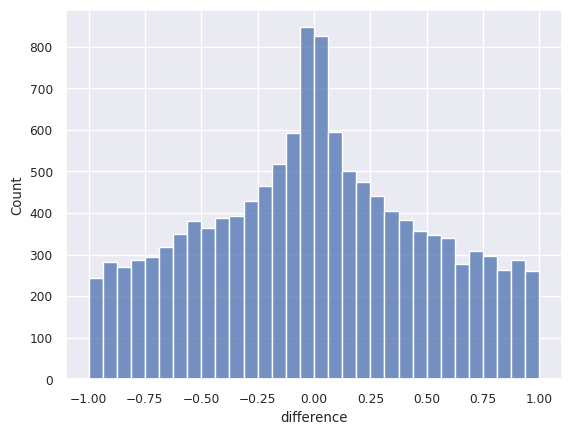

In [64]:
# turn cell_type_psi into a dataframe wtih columns cell_state1 and cell_state_2 based on index of column 
cell_type_psi_df = pd.DataFrame(cell_type_psi.numpy())
cell_type_psi_df.columns = ["cell_state_" + str(col) for col in cell_type_psi_df.columns]
cell_type_psi_df["new_junction_id_index"] = np.arange(cell_type_psi_df.shape[0])
cell_type_psi_df["difference"] = cell_type_psi_df["cell_state_1"] - cell_type_psi_df["cell_state_0"]
# plot histogram of difference
sns.histplot(cell_type_psi_df["difference"])

In [73]:
from scipy.sparse import coo_matrix
true_psi = (sim_juncs_counts / cluster_counts_sub)
true_psi[0, 0]

nan

In [76]:
# how many in true_psi are not nan ~ 10% of the data 
np.sum(~np.isnan(true_psi)) / (np.sum(~np.isnan(true_psi)) + np.sum(np.isnan(true_psi)))

0.1010009157417726

In [97]:
junc_tp = np.array(true_psi[:, 1677])
# Count the number of non-NaN values
print(np.sum(~np.isnan(junc_tp)))

# Calculate the median and mean of non-NaN values
print(np.unique(junc_tp))

305
[0.         0.00578035 0.00675676 0.00699301 0.00714286 0.00724638
 0.0078125  0.00884956 0.00934579 0.00985222 0.01       0.0106383
 0.0125     0.01342282 0.01382488 0.01388889 0.015625   0.01639344
 0.01694915 0.01818182 0.01886792 0.01923077 0.01941748 0.01960784
 0.01980198 0.02040816 0.02112676 0.02150538 0.02242152 0.02290076
 0.0233463  0.02380952 0.0239521  0.02409639 0.02461538 0.02465753
 0.02542373 0.02564103 0.02583026 0.02649007 0.02803738 0.02877698
 0.03030303 0.03225806 0.03278689 0.03296703 0.03333333 0.03370787
 0.03389831 0.03448276 0.03529412 0.03571429 0.03636364 0.0375
 0.03921569 0.04065041 0.04081633 0.04166667 0.04255319 0.04347826
 0.04444444 0.04716981 0.04761905 0.05       0.05494505 0.05555556
 0.05714286 0.07692308 0.08108108 0.08333333 0.09090909 0.1
 0.15384615 0.25       0.95       0.96153846 0.9625     0.96666667
 0.96774194 0.97142857 0.97435897 0.97619048 0.97826087 0.98305085
 0.98540146 0.98689956 0.98701299 0.9875     0.98765432 0.98901099
 0.

In [91]:
#get cell indices for new_cell_type==0 and new_cell_type==1
cell_type_0 = np.where(cell_types == 0)[0]
cell_type_1 = np.where(cell_types == 1)[0]

In [101]:
# summarize values for each cell type
print("Cell type 0:")
print("Median:", np.nanmedian(junc_tp[cell_type_0]))
print("Cell type 1:")
print("Median:", np.nanmedian(junc_tp[cell_type_1]))

Cell type 0:
Median: 0.9625
Cell type 1:
Median: 0.551923076923077


In [ ]:
# take the difference using the full simulated PSI matrix since these are the actual values 
# based on these differences assign positive and negative labels for junctions
# the cell_type_psi matrix is just a matrix of priors on the junctions 
# the true observed PSIs will depend on how many reads were in cluster in the cell  

In [77]:
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) > 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["difference"], inplace = True)
cell_type_psi_df.head()

,cell_state_0,cell_state_1,new_junction_id_index,difference,true_label
1677,0.999997,0.000067,1677,-0.999931,positive
9713,0.999902,0.000018,9713,-0.999884,positive
8780,0.999661,0.000005,8780,-0.999657,positive
12319,0.999169,0.000003,12319,-0.999166,positive
10808,0.998870,0.000193,10808,-0.998677,positive


In [27]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cells[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,54,0.0,1
1,0,55,66.0,1
2,0,56,19.0,1
3,0,69,4.0,1
4,0,70,3.0,1


In [28]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index,new_junc_count,new_cell_type
0,764,2,33.0,65,32.0,0.507692,C11-MAA000932-3_11_M-1-1_Brain_Non-Myeloid_end...,Brain_Non-Myeloid_endothelial_cell,10_100080130_100080856,74169,0,59.0,0
1,2450,2,108.0,202,94.0,0.534653,H18-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,10_100080130_100080856,74169,0,174.0,0
2,2424,2,53.0,100,47.0,0.530000,H16-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,10_100080130_100080856,74169,0,36.0,1
3,2408,2,10.0,13,3.0,0.769231,H15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_end...,Brain_Non-Myeloid_endothelial_cell,10_100080130_100080856,74169,0,5.0,1
4,2387,2,8.0,29,21.0,0.275862,H13-MAA001853-3_38_F-1-1_Brain_Non-Myeloid_end...,Brain_Non-Myeloid_endothelial_cell,10_100080130_100080856,74169,0,22.0,0


### Prep simulated data as input into mixture model

In [29]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,junction_id_index,junc_count,new_cell_type
0,764,65,32.0,0.507692,C11-MAA000932-3_11_M-1-1_Brain_Non-Myeloid_end...,Brain_Non-Myeloid_endothelial_cell,10_100080130_100080856,74169,0,59.0,0
1,2450,202,94.0,0.534653,H18-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,10_100080130_100080856,74169,0,174.0,0
2,2424,100,47.0,0.530000,H16-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte,10_100080130_100080856,74169,0,36.0,1
3,2408,13,3.0,0.769231,H15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_end...,Brain_Non-Myeloid_endothelial_cell,10_100080130_100080856,74169,0,5.0,1
4,2387,29,21.0,0.275862,H13-MAA001853-3_38_F-1-1_Brain_Non-Myeloid_end...,Brain_Non-Myeloid_endothelial_cell,10_100080130_100080856,74169,0,22.0,0


In [30]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
5499
5499


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:332: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [31]:
len(sim_data.junction_id_index.unique())

12786

### Check how well the data is simulated, is there cell type specific splicing?

In [32]:
# let's visualize junction usage ratios for each cell type 


### Run mixture model

In [33]:
K = 2
print(K)

2


In [34]:
# make new cell_ids_conversion dataframe using new cell type column
cell_ids_conversion_new = sim_data[["cell_id_index", "cell_type", "cell_id", "new_cell_type"]].drop_duplicates()
cell_ids_conversion_new.head()

,cell_id_index,cell_type,cell_id,new_cell_type
0,764,Brain_Non-Myeloid_endothelial_cell,C11-MAA000932-3_11_M-1-1_Brain_Non-Myeloid_end...,0
1,2450,Brain_Non-Myeloid_brain_pericyte,H18-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,0
2,2424,Brain_Non-Myeloid_brain_pericyte,H16-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,1
3,2408,Brain_Non-Myeloid_endothelial_cell,H15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_end...,1
4,2387,Brain_Non-Myeloid_endothelial_cell,H13-MAA001853-3_38_F-1-1_Brain_Non-Myeloid_end...,0


In [35]:
# set random seed
torch.manual_seed(0)

num_trials = 2 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 12786 junctions
Got the initial ELBO ^
ELBO converged @ -306539136.0 CAVI iteration # 5 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 12786 junctions
Got the initial ELBO ^
ELBO converged @ -306541248.0 CAVI iteration # 5 complete
Finished CAVI!
This took 0.5998656749725342 seconds


The trial with the highest ELBO was 0


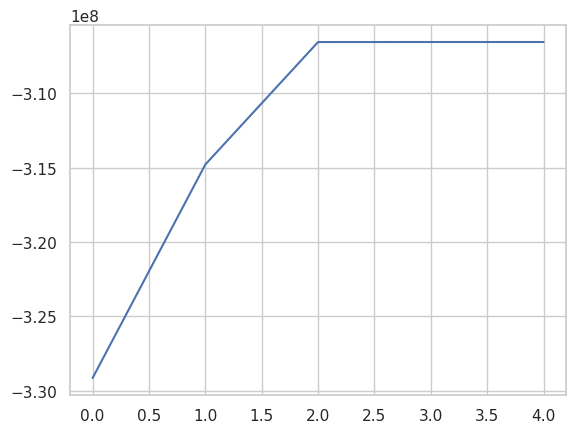

In [36]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

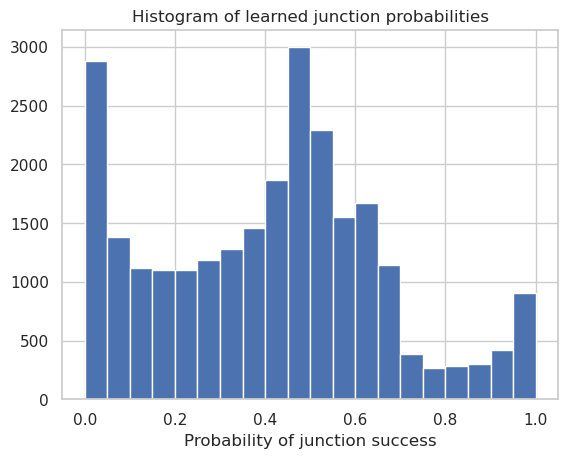

In [37]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
 
plt.hist(juncs_probs.cpu().numpy().flatten(), 20)
plt.title('Histogram of learned junction probabilities') 
plt.xlabel('Probability of junction success')
plt.show()

In [38]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()
PHI_f_plot

,0,1,cell_id
0,0.0,1.0,Brain_Myeloid_microglial_cell
1,0.0,1.0,Brain_Non-Myeloid_astrocyte
2,1.0,0.0,Brain_Non-Myeloid_oligodendrocyte
3,1.0,0.0,Brain_Non-Myeloid_endothelial_cell
4,1.0,0.0,Brain_Myeloid_microglial_cell
...,...,...,...
5494,0.0,1.0,Brain_Myeloid_macrophage
5495,0.0,1.0,Brain_Myeloid_microglial_cell
5496,1.0,0.0,Brain_Non-Myeloid_oligodendrocyte_precursor_cell
5497,0.0,1.0,Brain_Non-Myeloid_endothelial_cell


In [39]:
cell_ids_conversion_new.sort_values(by = ["cell_id_index"], inplace = True)
cell_ids_conversion_new.head()

,cell_id_index,cell_type,cell_id,new_cell_type
16199,0,Brain_Myeloid_microglial_cell,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,1
54591,1,Brain_Non-Myeloid_astrocyte,A1-B003728-3_56_F-1-1_Brain_Non-Myeloid_astrocyte,1
9548,2,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,0
4551,3,Brain_Non-Myeloid_endothelial_cell,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,0
3515,4,Brain_Myeloid_microglial_cell,A1-MAA000603-3_10_M-1-1_Brain_Myeloid_microgli...,0


In [40]:
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion_new['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_ids_conversion_new.new_cell_type.values
# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

Running! will make heatmap with cell types
Got all cells and their assignments based on PHI_f in each trial!


Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations
The number of trials is:  2
   Value     Count
2    2.0  15115571
0    0.0  15112434
1    1.0     10996


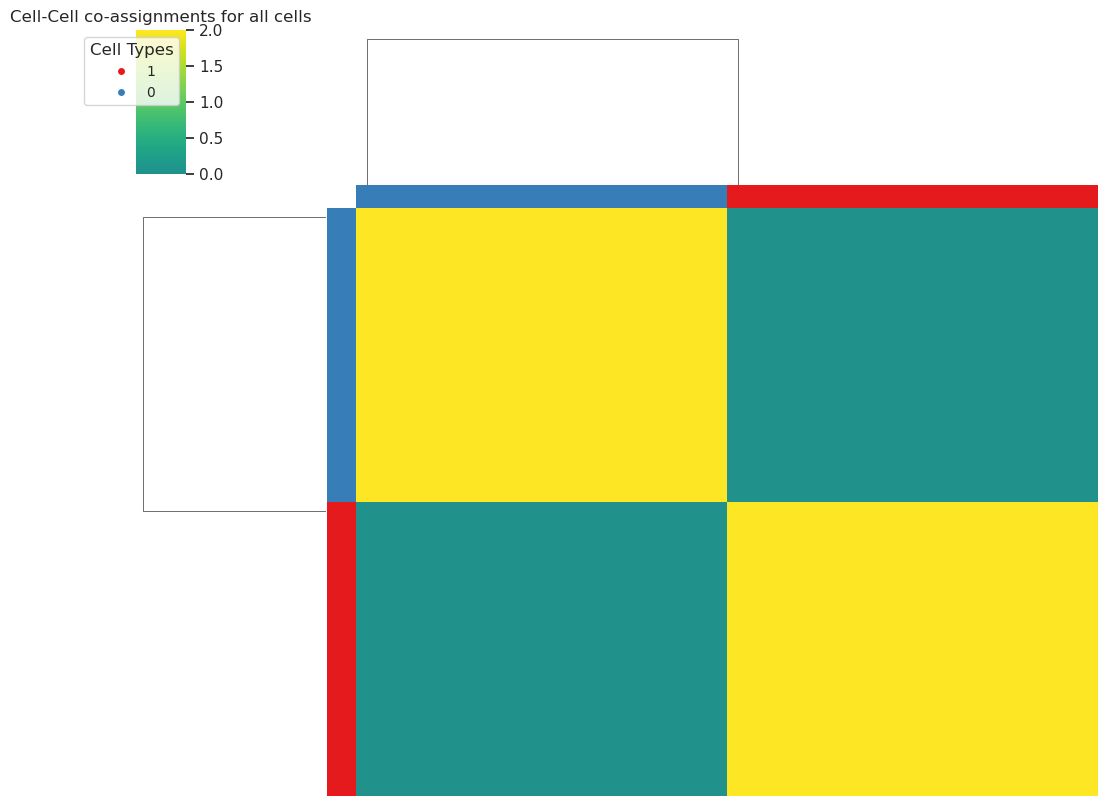

In [41]:
all_iters_results = check_cell_pairs(results, row_colors, col_colors, cell_type_colors, num_cells_to_plot=100)

In [42]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col) for col in juncs_probs_df.columns]
juncs_probs_df["new_junction_id_index"] = junction_ids_conversion.new_junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [43]:
juncs_probs_df

,cell_state_0,cell_state_1,new_junction_id_index,junction_id
0,0.583037,0.366497,0,10_100080130_100080856
1,0.024801,0.254135,1,10_100080130_100087346
2,0.039532,0.044717,2,10_100080940_100087346
3,0.415164,0.008216,3,10_100478022_100485050
4,0.911695,0.844498,4,10_100478022_100487161
...,...,...,...,...
12781,0.040241,0.268597,12781,Y_1280439_1284321
12782,0.594223,0.580920,12782,Y_1282948_1284321
12783,0.401191,0.045271,12783,Y_58849553_58853447
12784,0.443319,0.274938,12784,Y_58849553_58853675


In [44]:
def plot_juncObsUsage(junc_index):

    # print junction ID using junction_ids_conversion
    junc_id = junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index].junction_id.values[0]
    print(junc_id)

    # get data for just junc_index 
    junc_dat = sim_data[sim_data.junction_id == junc_id]
    print(junc_dat.new_cell_type.value_counts())

    # make violin plot for junc_dat junction usage ratio coloured by cell_type and rotate plot 90 degrees
    plot = ggplot(junc_dat, aes(x='new_cell_type', y='juncratio', fill="new_cell_type")) + geom_violin() + geom_point() + plotnine.labels.ggtitle(junc_id) + plotnine.coords.coord_flip() 

    # add number of cells in each cell_type to plot 
    print(plot)

def plot_juncProbs(junc_index):
    
    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index].junction_id.values[0]
    
    # get data for just junc_index 
    junc_dat = juncs_probs_df[juncs_probs_df.new_junction_id_index == junc_index]
    junc_dat = junc_dat.melt().iloc[0:K]
    junc_dat.value = junc_dat.value.astype(float)
    # make violin plot for junc_dat junction usage ratio coloured by cell_type
    # don't print x-axis tick labels 
    plot = ggplot(junc_dat, aes(x='variable', y='value')) + geom_point() + theme(axis_text_x=element_blank())
    print(plot)

In [45]:
scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["new_junction_id_index"] = junction_ids_conversion.new_junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test = scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).new_junction_id_index.values

In [46]:
sim_data["new_cell_type"] = sim_data["new_cell_type"].astype(str)

X_167208051_167208322
0    2700
1    2648
Name: new_cell_type, dtype: int64


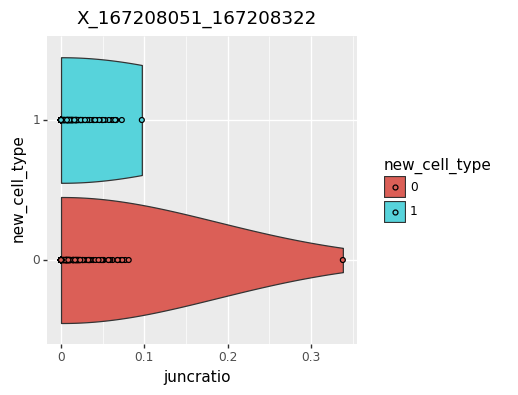


        junction_id_index            junction_id  Cluster  \
725223              77269  X_167208051_167208322   130614   

        new_junction_id_index  
725223                  12513  


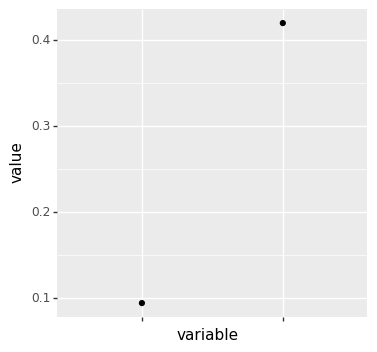


7_30414650_30415007
0    1611
1    1550
Name: new_cell_type, dtype: int64


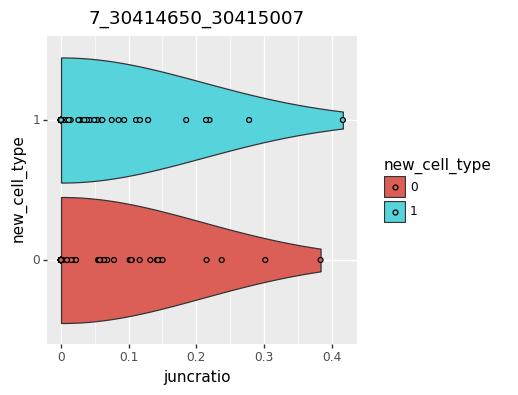


         junction_id_index          junction_id  Cluster  \
1105172              64455  7_30414650_30415007    49817   

         new_junction_id_index  
1105172                  10419  


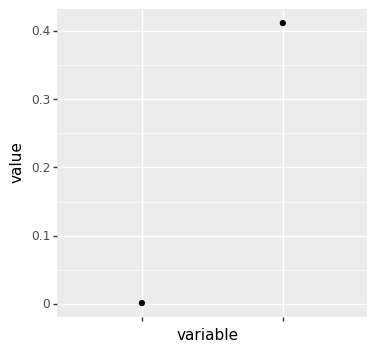

In [47]:
# for each junction in top10juncs_state1, run plot_juncObsUsage and plot_juncProbs
for junc in juncs_test:
    plot_juncObsUsage(junc)
    plot_juncProbs(junc)

In [48]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion_new.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion_new.new_cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_2086/4122663987.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_0,CellState_1
cell_type,,
0,2.778000e+03,2.026965e-22
1,1.128939e-19,2.721000e+03


In [49]:
PHI_f

,CellState_0,CellState_1,cell_id,cell_type
0,0.0,1.0,A1-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,1
1,0.0,1.0,A1-B003728-3_56_F-1-1_Brain_Non-Myeloid_astrocyte,1
2,1.0,0.0,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,0
3,1.0,0.0,A1-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_endo...,0
4,1.0,0.0,A1-MAA000603-3_10_M-1-1_Brain_Myeloid_microgli...,0
...,...,...,...,...
5494,0.0,1.0,P9-MAA000605-3_10_M-1-1_Brain_Myeloid_macrophage,1
5495,0.0,1.0,P9-MAA000617-3_10_M-1-1_Brain_Myeloid_microgli...,1
5496,1.0,0.0,P9-MAA000926-3_9_M-1-1_Brain_Non-Myeloid_oligo...,0
5497,0.0,1.0,P9-MAA000932-3_11_M-1-1_Brain_Non-Myeloid_endo...,1


/scratch/ipykernel_2086/1592633849.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_2086/1592633849.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


<Axes: ylabel='cell_type'>

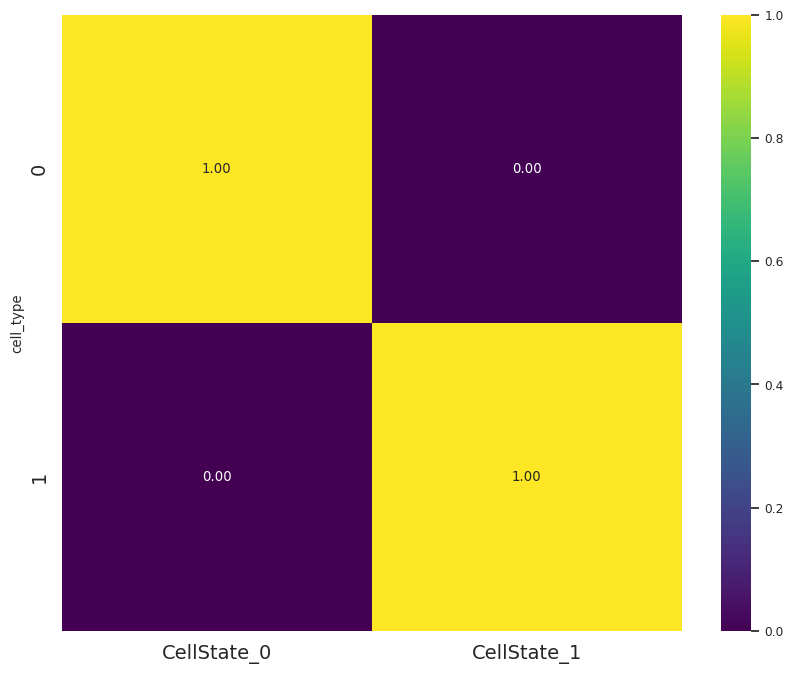

In [50]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(10, 8))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
sns.heatmap(sum_prop, annot=True, fmt=".2f", cmap='viridis')